# Device Distribution Visualisation Analysis

This notebook contains the data preparation and analysis used for the user-based visualisations in this project.

The notebook includes the original SQL extraction and processing steps used to create the analysis datasets from the project database.

If you have access to the SQL database, you can run the full notebook from the data extraction stage. If you are reviewing the repository without database access, you can skip the SQL processing section and load the exported CSV files saved in `../data/processed/` instead.

In [25]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# 1. Define connection details
server = 'localhost' # Your local server name as seen in SSMS
database_name = 'DataLensStreaming' # Updated to target the DataLens database

# 2. Create SQLAlchemy Engine
# Windows Authentication (Configured to match SSMS security requirements)
# Note: Encrypt=yes and TrustServerCertificate=yes added to prevent certificate chain errors
# Note: quote_plus is used to safely encode the ODBC connection string for SQLAlchemy
params = quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database_name};"
    f"Trusted_Connection=yes;"
    f"Encrypt=yes;"
    f"TrustServerCertificate=yes;"
)

connection_string = f"mssql+pyodbc:///?odbc_connect={params}"

engine = create_engine(connection_string)

# 3. Define SQL query mapping to the DataLens DB structure
my_query = """
    SELECT m.Movie_Title, m.Year, g.Genre_Name 
    FROM movies_clean m
    JOIN movie_genres mg ON m.MovieID = mg.MovieID
    JOIN genres g ON mg.GenreID = g.GenreID
"""

# 4. Execute query and store result as Pandas DataFrame
df = pd.read_sql(my_query, engine)

print(df.head())

  Movie_Title  Year  Genre_Name
0   Toy Story  1995   Animation
1   Toy Story  1995  Children's
2   Toy Story  1995      Comedy
3     Jumanji  1995   Adventure
4     Jumanji  1995  Children's


C:\Users\Andrew\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [109]:
# SQL Query for Users Table Data
user_query =  """
    SELECT *
    FROM Users
"""
user_df = pd.read_sql(user_query, engine)
print(user_df.head())
print(f"{len(user_df)} records")

# Save the Users table data to CSV for reuse in other notebooks
user_df.to_csv("../data/processed/device_distribution_users.csv", index=False)

    UserID  Age Gender Country SubscriptionStatus  TotalWatchTime   Device
0     SF_1   11      F   India               Free             231   Mobile
1    SF_10   65      F   Italy               Free             458   Mobile
2   SF_100   39      M   Italy         Subscriber             292  Desktop
3  SF_1000   23      F  France               Free             373  Desktop
4  SF_1001   43      M  France         Subscriber             249   Mobile
6040 records


In [90]:
# SQL Query for Raters (Users who have given ratings)
raters_query = """
    SELECT DISTINCT
        u.UserID,
        u.Age,
        u.Gender,
        u.Country,
        u.SubscriptionStatus,
        u.TotalWatchTime,
        u.Device,
        'Rater' AS Rating_Status
    FROM Users u
    INNER JOIN ratings_clean r
        ON u.UserID = r.UserID
"""
raters_df = pd.read_sql(raters_query, engine)
print(raters_df.head())
print(f"{len(raters_df)} records")

    UserID  Age Gender Country SubscriptionStatus  TotalWatchTime    Device  \
0    SF_10   65      F   Italy               Free             458    Mobile   
1   SF_100   39      M   Italy         Subscriber             292   Desktop   
2  SF_1001   43      M  France         Subscriber             249    Mobile   
3  SF_1003   42      M  France         Subscriber             203    Tablet   
4  SF_1006   47      M     USA               Free             409  Smart TV   

  Rating_Status  
0         Rater  
1         Rater  
2         Rater  
3         Rater  
4         Rater  
4915 records


In [87]:
# SQL Query for Non-Raters (Users who have not given ratings)
non_raters_query = """
    SELECT DISTINCT
        u.UserID,
        u.Age,
        u.Gender,
        u.Country,
        u.SubscriptionStatus,
        u.TotalWatchTime,
        u.Device,
        'Non-rater' AS Rating_Status
    FROM Users u
    LEFT JOIN ratings_clean r
        ON u.UserID = r.UserID
    WHERE r.UserID IS NULL
"""
non_raters_df = pd.read_sql(non_raters_query, engine)
print(non_raters_df.head())
print(f"{len(non_raters_df)} records")

    UserID  Age Gender Country SubscriptionStatus  TotalWatchTime    Device  \
0     SF_1   11      F   India               Free             231    Mobile   
1  SF_1000   23      F  France               Free             373   Desktop   
2  SF_1002   56      M     USA               Free              30    Tablet   
3  SF_1004   39      M   India               Free             453    Tablet   
4  SF_1005    9      M     USA         Subscriber             475  Smart TV   

  Rating_Status  
0     Non-rater  
1     Non-rater  
2     Non-rater  
3     Non-rater  
4     Non-rater  
1125 records


In [93]:
# Combine raters and non-raters into one dataframe
raters_non_raters_df = pd.concat([raters_df, non_raters_df], ignore_index=True)

# Check the combined result
print(raters_non_raters_df.head())
print(f"{len(raters_non_raters_df)} records")

# Save the rater details to CSV for reuse
raters_non_raters_df.to_csv("../data/processed/device_distribution_raters_non_raters.csv", index=False)

    UserID  Age Gender Country SubscriptionStatus  TotalWatchTime    Device  \
0    SF_10   65      F   Italy               Free             458    Mobile   
1   SF_100   39      M   Italy         Subscriber             292   Desktop   
2  SF_1001   43      M  France         Subscriber             249    Mobile   
3  SF_1003   42      M  France         Subscriber             203    Tablet   
4  SF_1006   47      M     USA               Free             409  Smart TV   

  Rating_Status  
0         Rater  
1         Rater  
2         Rater  
3         Rater  
4         Rater  
6040 records


In [97]:
# SQL Query for Genres of Movies Rated and the Devices Used
genre_device_query = """
SELECT DISTINCT
    u.UserID,
    u.Age,
    u.Gender,
    u.Country,
    u.SubscriptionStatus,
    u.TotalWatchTime,
    u.Device,
    'Rater' AS Rating_Status,
    m.Movie_Title,
    g.Genre_Name
FROM Users u
INNER JOIN ratings_clean r
    ON u.UserID = r.UserID
INNER JOIN movies_clean m
    ON r.MovieID = m.MovieID
INNER JOIN movie_genres mg
    ON m.MovieID = mg.MovieID
INNER JOIN genres g
    ON mg.GenreID = g.GenreID
"""

genre_device_df = pd.read_sql(genre_device_query, engine)
print(genre_device_df.head())
print(f"{len(genre_device_df)} records")

# Save the rater details to CSV for reuse
genre_device_df.to_csv("../data/processed/device_distribution_genre_device.csv", index=False)

    UserID  Age Gender Country SubscriptionStatus  TotalWatchTime   Device  \
0    SF_10   65      F   Italy               Free             458   Mobile   
1    SF_10   65      F   Italy               Free             458   Mobile   
2   SF_100   39      M   Italy         Subscriber             292  Desktop   
3  SF_1001   43      M  France         Subscriber             249   Mobile   
4  SF_1003   42      M  France         Subscriber             203   Tablet   

  Rating_Status                                        Movie_Title Genre_Name  
0         Rater                                      Funhouse, The     Horror  
1         Rater  Return of Martin Guerre, The (Retour de Martin...      Drama  
2         Rater                                   Juno and Paycock      Drama  
3         Rater                                              Rosie      Drama  
4         Rater                                   Devil's Own, The     Action  
16457 records


## Load exported datasets

The SQL extraction and processing cells above were used to generate the datasets for this notebook.

For repository review, these processed datasets have been saved as CSV files in `../data/processed/` so the remaining analysis and visualisations can be run without a live SQL connection.

Run the next cell to load the exported CSV files directly into pandas DataFrames.

In [110]:
# Load processed CSV files from the repository
# These files are provided so the notebooks can run without a live SQL connection
# Update the file paths below if your folder structure is different

import pandas as pd

user_df = pd.read_csv("../data/processed/device_distribution_users.csv")
raters_df = pd.read_csv("../data/processed/device_distribution_raters_non_raters.csv")
device_genre_df = pd.read_csv("../data/processed/device_distribution_genre_device.csv")

# Preview the loaded data
print("Users data:")
print(user_df.head())

print("\nRaters data:")
print(raters_df.head())

print("\nDevice by genre data:")
print(genre_device_df.head())

Users data:
    UserID  Age Gender Country SubscriptionStatus  TotalWatchTime   Device
0     SF_1   11      F   India               Free             231   Mobile
1    SF_10   65      F   Italy               Free             458   Mobile
2   SF_100   39      M   Italy         Subscriber             292  Desktop
3  SF_1000   23      F  France               Free             373  Desktop
4  SF_1001   43      M  France         Subscriber             249   Mobile

Raters data:
    UserID  Age Gender Country SubscriptionStatus  TotalWatchTime    Device  \
0    SF_10   65      F   Italy               Free             458    Mobile   
1   SF_100   39      M   Italy         Subscriber             292   Desktop   
2  SF_1001   43      M  France         Subscriber             249    Mobile   
3  SF_1003   42      M  France         Subscriber             203    Tablet   
4  SF_1006   47      M     USA               Free             409  Smart TV   

  Rating_Status  
0         Rater  
1         Rat

In [111]:
import pandas as pd
import numpy as np

# Define the numerical boundaries for age groups
# This creates bins for: 0-17, 18-34, 35-54, and 55 to inf
# The groups reflect distinct user life stages or behaviors (e.g., high school, young professionals, parents, retirees)
age_bins = [0, 17, 34, 54, np.inf]

# Define the text labels for those bins
age_labels = ['Under 18', '18-34', '35-54', '55+']

# Create the new column
user_df['Age_Group'] = pd.cut(user_df['Age'], bins=age_bins, labels=age_labels)

# Define the numerical boundaries for watch time
# This creates bins for: 0-99, 100-249, 250-399, 400 to inf
watchtime_bins = [0, 99, 249, 399, np.inf]

# Define the text labels for those bins
watchtime_labels = ['Light Viewer', 'Moderate Viewer', 'Frequent Viewer', 'Super Viewer']

# Create the new column
user_df['Watch_Time_Category'] = pd.cut(user_df['TotalWatchTime'], bins=watchtime_bins, labels=watchtime_labels)

print(user_df.head())

    UserID  Age Gender Country SubscriptionStatus  TotalWatchTime   Device  \
0     SF_1   11      F   India               Free             231   Mobile   
1    SF_10   65      F   Italy               Free             458   Mobile   
2   SF_100   39      M   Italy         Subscriber             292  Desktop   
3  SF_1000   23      F  France               Free             373  Desktop   
4  SF_1001   43      M  France         Subscriber             249   Mobile   

  Age_Group Watch_Time_Category  
0  Under 18     Moderate Viewer  
1       55+        Super Viewer  
2     35-54     Frequent Viewer  
3     18-34     Frequent Viewer  
4     35-54     Moderate Viewer  


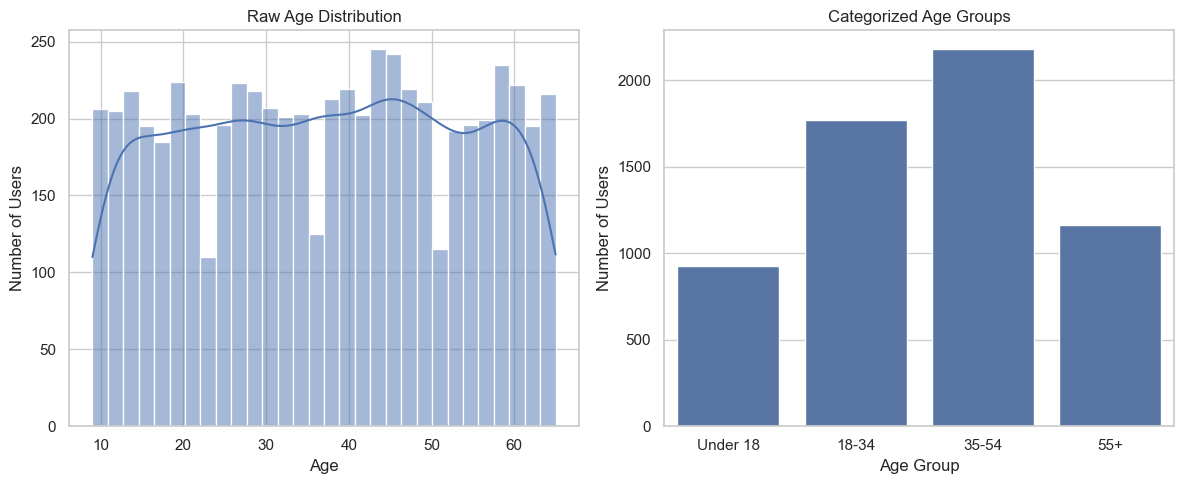

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure space
plt.figure(figsize=(12, 5))

# 1. Plot the raw distribution (very narrow bins to see the true shape)
plt.subplot(1, 2, 1)
sns.histplot(user_df['Age'], bins=30, kde=True)
plt.title('Raw Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Users')

# 2. Plot your custom age groups
plt.subplot(1, 2, 2)
sns.countplot(data=user_df, x='Age_Group', order=['Under 18', '18-34', '35-54', '55+'])
plt.title('Categorized Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

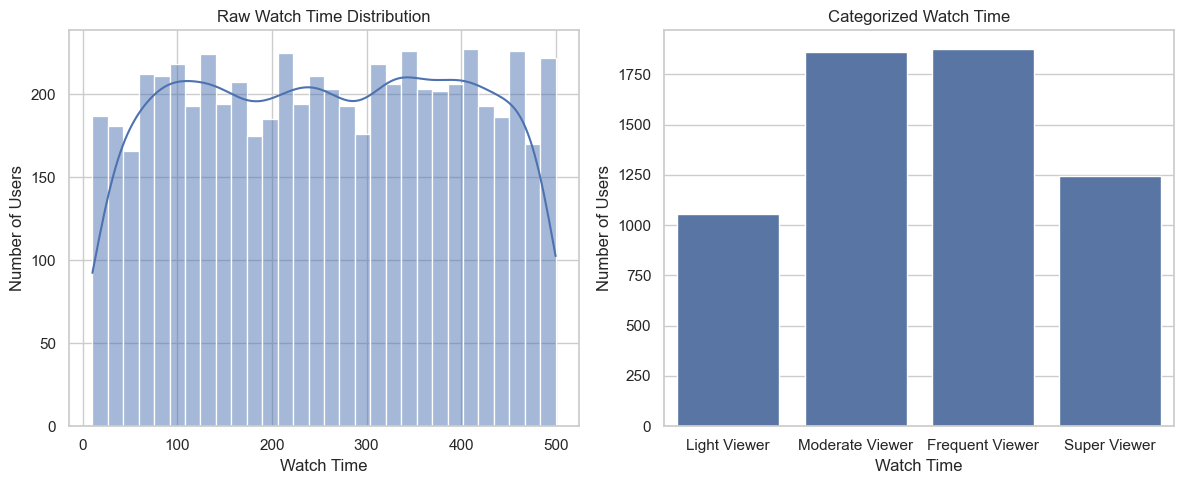

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure space
plt.figure(figsize=(12, 5))

# 1. Plot the raw distribution (very narrow bins to see the true shape)
plt.subplot(1, 2, 1)
sns.histplot(user_df['TotalWatchTime'], bins=30, kde=True)
plt.title('Raw Watch Time Distribution')
plt.xlabel('Watch Time')
plt.ylabel('Number of Users')

# 2. Plot your custom age groups
plt.subplot(1, 2, 2)
sns.countplot(data=user_df, x='Watch_Time_Category', order=['Light Viewer', 'Moderate Viewer', 'Frequent Viewer', 'Super Viewer'])
plt.title('Categorized Watch Time')
plt.xlabel('Watch Time')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

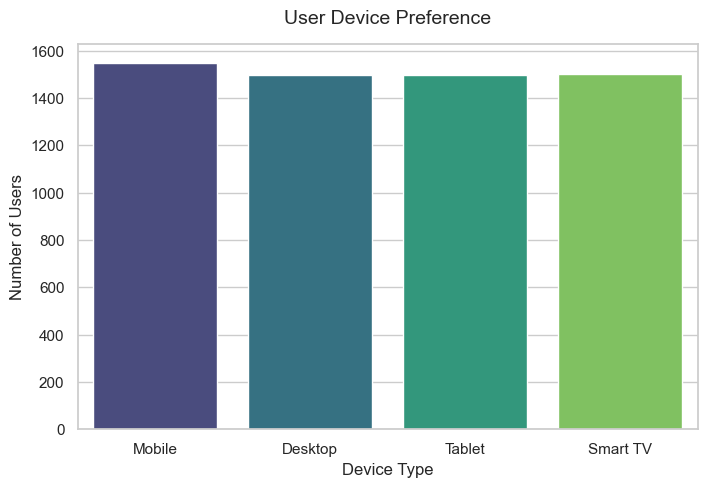

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=user_df, x='Device', hue='Device', palette='viridis', legend=False)

plt.title('User Device Preference', fontsize=14, pad=15)
plt.xlabel('Device Type', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)

plt.show()

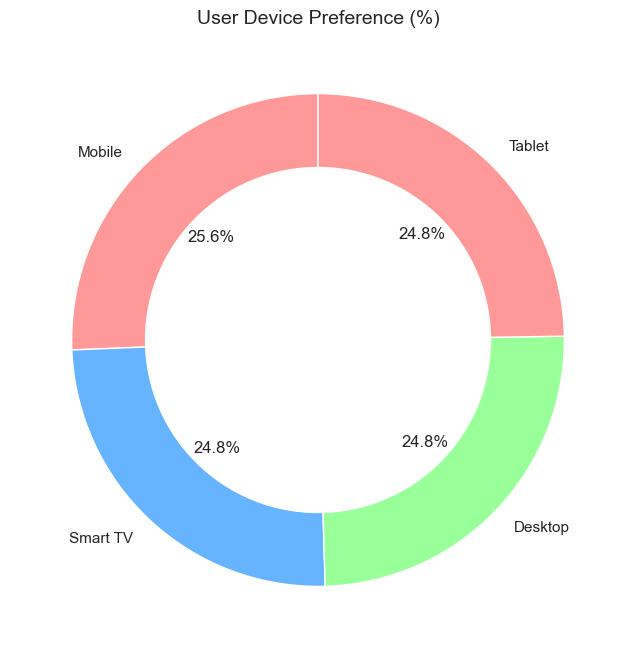

In [116]:
import matplotlib.pyplot as plt

# Count the exact number of uses for each device
device_counts = user_df['Device'].value_counts()

# Create the Donut Chart
plt.figure(figsize=(8, 8))
plt.pie(device_counts, labels=device_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])

# Draw a white circle in the center to turn the pie into a donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('User Device Preference (%)', fontsize=14)
plt.show()

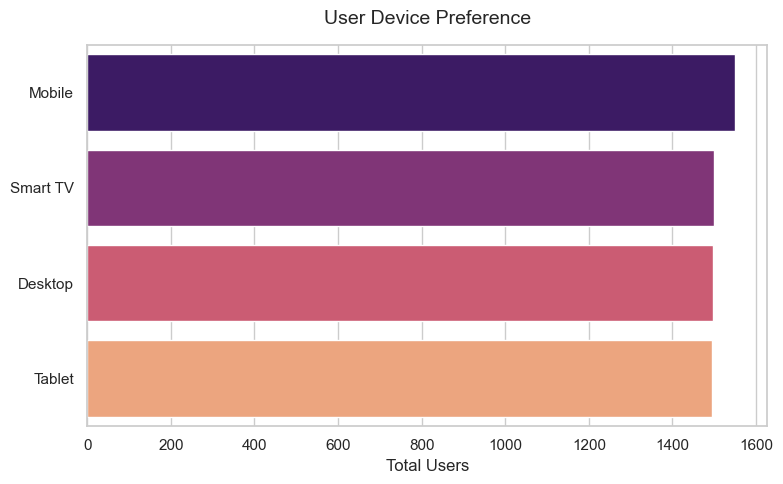

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts and sort them from highest to lowest
device_counts = user_df['Device'].value_counts().reset_index()
device_counts.columns = ['Device', 'Count']

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=device_counts,
    x='Count',
    y='Device',
    hue='Device',
    palette='magma',
    legend=False
)

plt.title('User Device Preference', fontsize=14, pad=15)
plt.xlabel('Total Users', fontsize=12)
plt.ylabel('', fontsize=12)  # Hide the y-label since the categories are self-explanatory

plt.tight_layout()
plt.show()

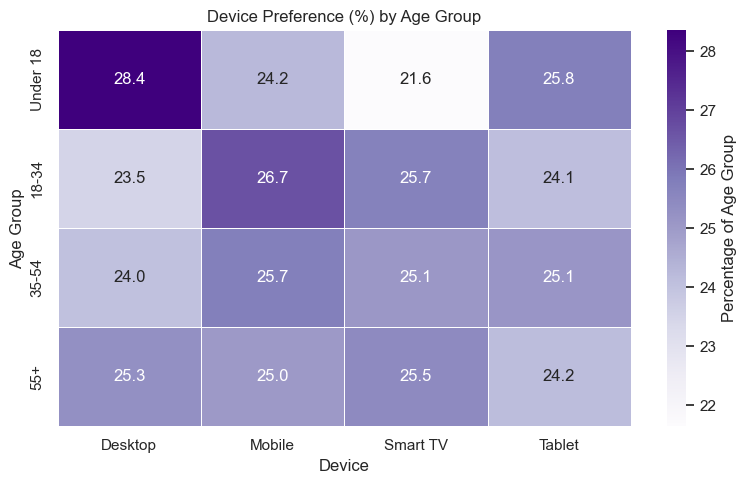

In [118]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the cross-tabulation (as percentages across the row)
device_by_age = pd.crosstab(
    user_df['Age_Group'], 
    user_df['Device'], 
    normalize='index'
) * 100

# 2. Visualize it using a Seaborn Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    device_by_age, 
    annot=True,
    fmt=".1f",
    cmap="Purples",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'label': 'Percentage of Age Group'}
)

plt.title('Device Preference (%) by Age Group')
plt.ylabel('Age Group')
plt.xlabel('Device')
plt.tight_layout()
plt.show()

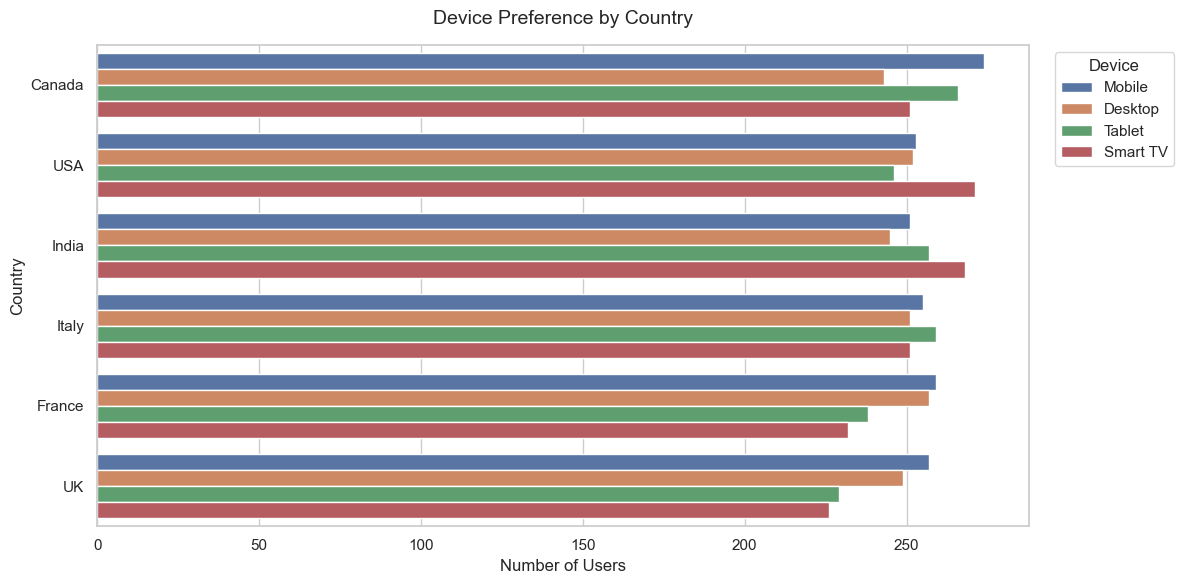

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

top_countries = user_df['Country'].value_counts().head(10).index
plot_df = user_df[user_df['Country'].isin(top_countries)]

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=plot_df,
    y='Country',
    hue='Device',
    order=top_countries,
    palette='deep'
)

plt.title('Device Preference by Country', fontsize=14, pad=15)
plt.xlabel('Number of Users', fontsize=12)
plt.ylabel('Country', fontsize=12)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title='Device', frameon=True)

plt.tight_layout()
plt.show()

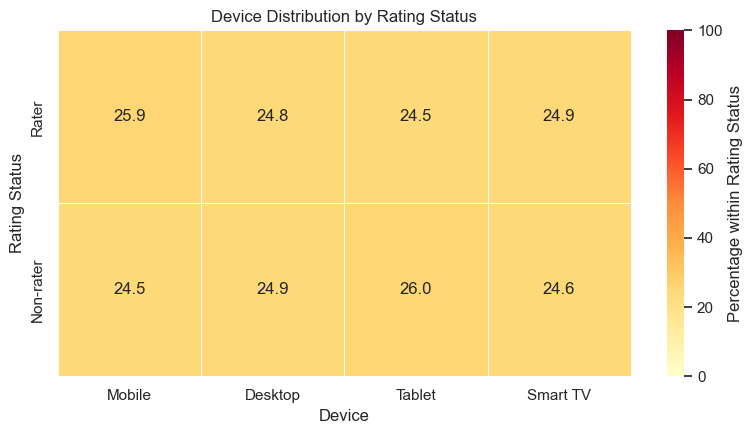

In [120]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rating_order = ['Rater', 'Non-rater']
device_order = ['Mobile', 'Desktop', 'Tablet', 'Smart TV']

rating_device = pd.crosstab(
    raters_non_raters_df['Rating_Status'],
    raters_non_raters_df['Device'],
    normalize='index'
) * 100

rating_device = rating_device.reindex(index=rating_order, columns=device_order)

plt.figure(figsize=(8, 4.5))
ax = sns.heatmap(
    rating_device,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Percentage within Rating Status'}
)

plt.title('Device Distribution by Rating Status')
plt.ylabel('Rating Status')
plt.xlabel('Device')
plt.tight_layout()
plt.show()

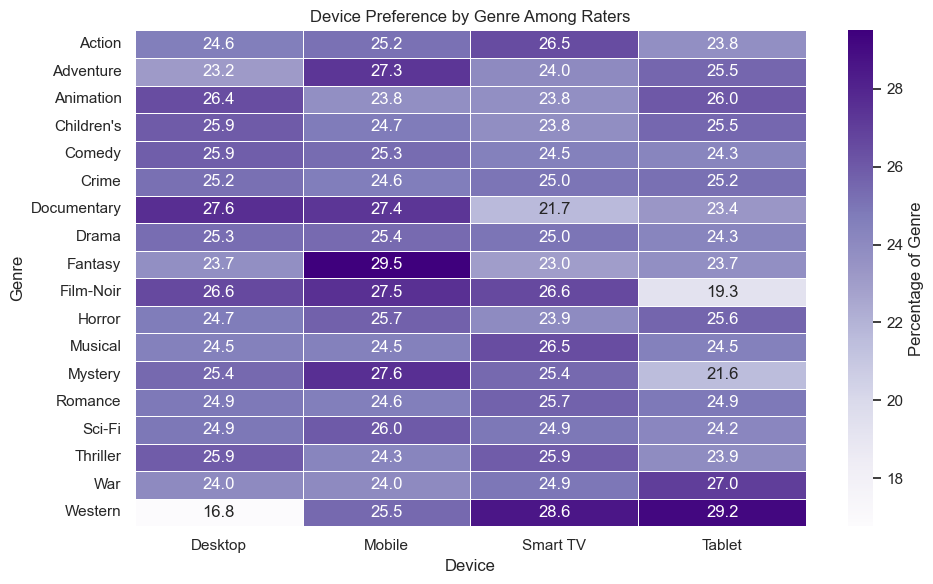

In [126]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the cross-tabulation (as percentages across each genre)
genre_by_device = pd.crosstab(
    genre_device_df['Genre_Name'],
    genre_device_df['Device'],
    normalize='index'
) * 100

# 2. Visualize it using a Seaborn Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    genre_by_device,
    annot=True,
    fmt=".1f",
    cmap="Purples",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'label': 'Percentage of Genre'}
)

plt.title('Device Preference by Genre Among Raters')
plt.ylabel('Genre')
plt.xlabel('Device')
plt.tight_layout()
plt.show()